# Manifold Learning

In [2]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [3]:
import pandas as pd
import numpy as np
import os

sample_df = pd.read_csv("sample_df.csv")
sample_df.head()

,Unnamed: 0,m_phi,mA,alpha,beta,lambda6,lambda7,m12,positivity_ok,unitarity_ok,...,w_h2_bb,w_h2_tautau,w_h2_WW,w_h2_ZZ,w_h2_gaga,w_h2_Zga,w_h2_gg,w_h2_hh,w_total_h2,branching_ratio_h2_gaga
0,0,125,320.0,-0.7,0.5,-0.5727,-1.0,-1.000000,1,1,...,0.0,0.0,0.000002,0.000014,0.000002,8.769151e-07,0.0,0.0,0.000127,0.01387
1,1,125,320.0,-0.7,0.5,-0.5727,-1.0,-0.565727,1,1,...,0.0,0.0,0.000002,0.000014,0.000002,8.769149e-07,0.0,0.0,0.000127,0.01387
2,2,125,320.0,-0.7,0.5,-0.5727,-1.0,-0.131454,1,1,...,0.0,0.0,0.000002,0.000014,0.000002,8.769147e-07,0.0,0.0,0.000127,0.01387
3,3,125,320.0,-0.7,0.5,-0.5727,-1.0,0.302819,1,1,...,0.0,0.0,0.000002,0.000014,0.000002,8.769144e-07,0.0,0.0,0.000127,0.01387
4,4,125,320.0,-0.7,0.5,-0.5727,-1.0,0.737092,1,1,...,0.0,0.0,0.000002,0.000014,0.000002,8.769142e-07,0.0,0.0,0.000127,0.01387


Muestra para ML4: 16032 registros.
Proyección realizada con t-SNE.


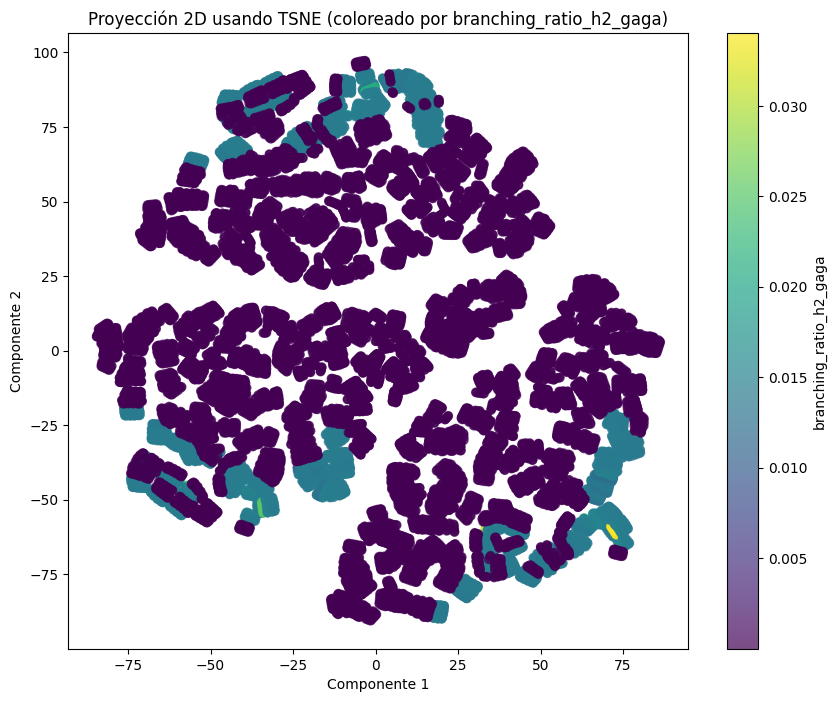

DBSCAN encontró 73 clusters (excluyendo ruido).


C:\Users\fbien.DESKTOP-6FMEAR7\AppData\Local\temp\ipykernel_15608\1794980708.py:135: UserWarning: Adding colorbar to a different Figure <Figure size 1000x800 with 3 Axes> than <Figure size 1000x800 with 1 Axes> which fig.colorbar is called on.
  plt.colorbar(sc, label=TARGET_COL)


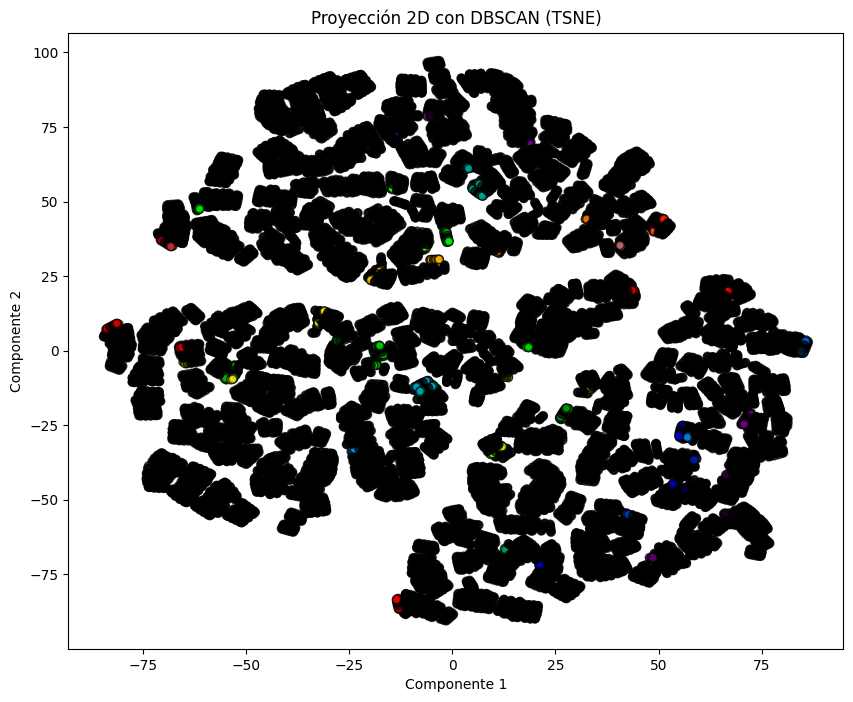

Resumen de clusters (etiqueta: cantidad):
-1     15612
 0         7
 1         5
 2         5
 3         6
       ...  
 68        7
 69        6
 70        6
 71        6
 72        5
Name: count, Length: 74, dtype: int64

Resumen de parámetros y resultados de ML4:
  ALGORITHM: tsne
  SAMPLE_SIZE: 50000
  REMOVE_OUTLIERS: False
  UMAP_N_NEIGHBORS: None
  UMAP_MIN_DIST: None
  TSNE_PERPLEXITY: 30
  APPLY_CLUSTERING: True
  DBSCAN_EPS: 0.5
  DBSCAN_MIN_SAMPLES: 5
  n_clusters: 73
Resumen guardado en ml4_outputs\ml4_summary.txt


In [4]:
# %% ML4: Manifold Learning para Identificar Regiones Inestables
# Objetivo: Proyectar el espacio de 7 dimensiones a 2D, visualizando la distribución de 
# puntos en función de la "estabilidad" (usando el branching ratio) y detectar subespacios.

# ------------------ Variables Globales Modificables ------------------
# Tamaño de la muestra a utilizar (por ejemplo, entre 1e5 y 1e6 puntos)
SAMPLE_SIZE = 50000  

# Columnas de parámetros y columna de estabilidad (branching ratio)
PARAM_COLS = ['m_phi', 'mA', 'alpha', 'beta', 'lambda6', 'lambda7', 'm12']
TARGET_COL = "branching_ratio_h2_gaga"  # Se utilizará como variable de estabilidad

# Preprocesamiento: Si se desea eliminar outliers extremos, se puede activar la opción
REMOVE_OUTLIERS = False  
OUTLIER_FACTOR = 1.5  # Factor IQR para outliers

# Selección de algoritmo de reducción de dimensionalidad: 'umap' o 'tsne'
ALGORITHM = 'tsne'  
# Parámetros para UMAP
UMAP_N_NEIGHBORS = 15
UMAP_MIN_DIST = 0.1
# Parámetros para t-SNE (si se elige)
TSNE_PERPLEXITY = 30

# Clustering opcional sobre la proyección
APPLY_CLUSTERING = True
# Parámetros de DBSCAN
DBSCAN_EPS = 0.5
DBSCAN_MIN_SAMPLES = 5

# Opcional: Ruta para guardar los gráficos generados
SAVE_GRAPHS = True
OUTPUT_DIR = "ml4_outputs"
if SAVE_GRAPHS and not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# ------------------ Funciones Auxiliares ------------------
def remove_outliers_iqr(df, cols, factor=1.5):
    """Elimina outliers usando el rango intercuartílico (IQR) para las columnas especificadas."""
    df_clean = df.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    return df_clean

# ------------------ Paso 1: Selección de Muestra Representativa ------------------
# Se asume que ya se dispone de una variable "sample_df" con los datos evaluados, que contenga 
# al menos las columnas definidas en PARAM_COLS y TARGET_COL.
# Si no existe, se debe generar a partir del pipeline previo.

try:
    sample_df  # Verifica que la variable existe
except NameError:
    raise NameError("La variable 'sample_df' no está definida. Asegúrate de ejecutar el pipeline de muestreo previamente.")

# Reducir o muestrear la muestra para que tenga SAMPLE_SIZE registros (aleatorio)
if sample_df.shape[0] > SAMPLE_SIZE:
    sample_df = sample_df.sample(n=SAMPLE_SIZE, random_state=42)
print(f"Muestra para ML4: {sample_df.shape[0]} registros.")

# ------------------ Paso 2: Preprocesamiento de Datos ------------------
# Normalizar/estandarizar las columnas de parámetros

scaler = StandardScaler()
X = sample_df[PARAM_COLS].values
X_scaled = scaler.fit_transform(X)
# Agregar el target (estabilidad) para visualización
y_stability = sample_df[TARGET_COL].values

# Opcional: eliminar outliers extremos
if REMOVE_OUTLIERS:
    df_preprocessed = pd.DataFrame(X_scaled, columns=PARAM_COLS)
    df_preprocessed[TARGET_COL] = y_stability
    df_preprocessed = remove_outliers_iqr(df_preprocessed, PARAM_COLS + [TARGET_COL], factor=OUTLIER_FACTOR)
    X_scaled = scaler.fit_transform(df_preprocessed[PARAM_COLS].values)
    y_stability = df_preprocessed[TARGET_COL].values
    print(f"Después de eliminar outliers, registros: {df_preprocessed.shape[0]}")
else:
    df_preprocessed = pd.DataFrame(X_scaled, columns=PARAM_COLS)
    df_preprocessed[TARGET_COL] = y_stability

# ------------------ Paso 3: Reducción de Dimensionalidad (Manifold Learning) ------------------
if ALGORITHM.lower() == 'umap':
    try:
        import umap
    except ImportError:
        raise ImportError("El paquete 'umap-learn' no está instalado. Instálalo con 'pip install umap-learn'.")
    reducer = umap.UMAP(n_neighbors=UMAP_N_NEIGHBORS, min_dist=UMAP_MIN_DIST, random_state=42)
    embedding = reducer.fit_transform(X_scaled)
    print("Proyección realizada con UMAP.")
elif ALGORITHM.lower() == 'tsne':
    from sklearn.manifold import TSNE
    reducer = TSNE(n_components=2, perplexity=TSNE_PERPLEXITY, random_state=42)
    embedding = reducer.fit_transform(X_scaled)
    print("Proyección realizada con t-SNE.")
else:
    raise ValueError("ALGORITHM debe ser 'umap' o 'tsne'.")

# ------------------ Paso 4: Visualización de la Proyección ------------------


plt.figure(figsize=(10, 8))
sc = plt.scatter(embedding[:, 0], embedding[:, 1], c=y_stability, cmap='viridis', alpha=0.7)
plt.colorbar(sc, label=TARGET_COL)
plt.title(f"Proyección 2D usando {ALGORITHM.upper()} (coloreado por {TARGET_COL})")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
if SAVE_GRAPHS:
    plt.savefig(os.path.join(OUTPUT_DIR, f"projection_{ALGORITHM}.png"), dpi=300)
plt.show()

# ------------------ Paso 5: Análisis y Detección de Subespacios con Clustering (Opcional) ------------------
if APPLY_CLUSTERING:
    try:
        from sklearn.cluster import DBSCAN
    except ImportError:
        raise ImportError("El paquete scikit-learn debe estar instalado para clustering.")
    clustering_model = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES)
    cluster_labels = clustering_model.fit_predict(embedding)
    n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    print(f"DBSCAN encontró {n_clusters} clusters (excluyendo ruido).")
    
    # Visualizar la proyección con clusters
    plt.figure(figsize=(10, 8))
    unique_labels = np.unique(cluster_labels)
    colors = cm.nipy_spectral(cluster_labels.astype(float) / (len(unique_labels) if len(unique_labels) > 0 else 1))
    plt.scatter(embedding[:, 0], embedding[:, 1], c=colors, alpha=0.7, edgecolor='k')
    plt.title(f"Proyección 2D con DBSCAN ({ALGORITHM.upper()})")
    plt.xlabel("Componente 1")
    plt.ylabel("Componente 2")
    plt.colorbar(sc, label=TARGET_COL)
    if SAVE_GRAPHS:
        plt.savefig(os.path.join(OUTPUT_DIR, f"projection_{ALGORITHM}_dbscan.png"), dpi=300)
    plt.show()
    
    # Imprimir resumen de clusters
    cluster_summary = pd.Series(cluster_labels).value_counts().sort_index()
    print("Resumen de clusters (etiqueta: cantidad):")
    print(cluster_summary)
else:
    print("Clustering no aplicado (APPLY_CLUSTERING=False).")

# ------------------ Paso 6: Documentación y Exportación de Resultados ------------------
# Exportar un resumen de la proyección y parámetros usados
summary = {
    "ALGORITHM": ALGORITHM,
    "SAMPLE_SIZE": SAMPLE_SIZE,
    "REMOVE_OUTLIERS": REMOVE_OUTLIERS,
    "UMAP_N_NEIGHBORS": UMAP_N_NEIGHBORS if ALGORITHM.lower() == 'umap' else None,
    "UMAP_MIN_DIST": UMAP_MIN_DIST if ALGORITHM.lower() == 'umap' else None,
    "TSNE_PERPLEXITY": TSNE_PERPLEXITY if ALGORITHM.lower() == 'tsne' else None,
    "APPLY_CLUSTERING": APPLY_CLUSTERING,
    "DBSCAN_EPS": DBSCAN_EPS if APPLY_CLUSTERING else None,
    "DBSCAN_MIN_SAMPLES": DBSCAN_MIN_SAMPLES if APPLY_CLUSTERING else None,
    "n_clusters": n_clusters if APPLY_CLUSTERING else "No clustering"
}

print("\nResumen de parámetros y resultados de ML4:")
for key, value in summary.items():
    print(f"  {key}: {value}")

# Opcional: Guardar el resumen en un archivo de texto
if SAVE_GRAPHS:
    summary_file = os.path.join(OUTPUT_DIR, "ml4_summary.txt")
    with open(summary_file, "w") as f:
        for key, value in summary.items():
            f.write(f"{key}: {value}\n")
    print(f"Resumen guardado en {summary_file}")
